In [1]:
#!/usr/bin/env python
# coding: utf-8
"""
grid_agnostic_closed_loop_exp6_stable_v2.py

Closed-loop (multi-step) rollout training for 1D KS-like fields, grid-agnostic across resolutions.

Key fixes for compounding error:
- chain-consistent rollouts (build chains where Y[i] ~= X[i+1], then split inside chains)
- scheduled sampling (teacher forcing -> free-run)
- per-resolution normalization (divisor 1/2/4)
- multi-term loss: state (u), increment (du), gradient, spectrum, stats
- bounded Δu head (tanh clip) to prevent runaway
- include dx scalar so model knows resolution
"""

import os, math, random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# -------------------------------
# Repro / device
# -------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 1337
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if DEVICE == "cuda":
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

# -------------------------------
# Paths
# -------------------------------
DATA_DIR = Path("/scratch/pp3051/weather")  # change if needed
SAVE_DIR = Path("./runs_grid_agnostic_closed_loop_exp6_stable_v2")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print(f"[info] device={DEVICE}")
print(f"[info] Loading data from {DATA_DIR.resolve()}")

# -------------------------------
# Hyperparameters
# -------------------------------
FREQS = (1, 2, 4, 8)
DIVISORS = (1, 2, 4)

INCLUDE_DX_SCALAR = True

BATCH_SIZE = 64 if DEVICE == "cuda" else 32
NUM_WORKERS = 0 if DEVICE != "cuda" else min(8, os.cpu_count() or 1)

# step-based training (steps == batches)
TOTAL_STEPS = 120_000
EVAL_EVERY = 2000
LOG_EVERY = 200
GRAD_CLIP = 1.0

LR_START = 2e-4
LR_MAX   = 2e-3
LR_MIN   = 2e-5
WARMUP_STEPS = 5000

WEIGHT_DECAY = 1e-4
DROPOUT_P = 0.10
# If compounding error is stubborn, try: NORM_TYPE="layer"
NORM_TYPE = "batch"  # "batch" or "layer"

# closed-loop / curriculum
MAX_K = 8
CURR_K = 1
ROLLOUT_ALPHA = 0.20
MIN_STEPS_PER_K = 20_000
PLATEAU_PATIENCE = 3
MIN_IMPROVE = 1e-4

# scheduled sampling (teacher forcing prob)
TF_START = 0.90
TF_END   = 0.00
TF_DECAY_STEPS = 60_000

# noise injected into normalized u inputs during training
INPUT_NOISE_STD = 0.01

# loss mix 
BETA_DU      = 0.50   # weight of du loss vs u loss
LAMBDA_GRAD  = 0.05   # gradient matching
LAMBDA_STATS = 0.001  # mean/std matching
LAMBDA_FFT   = 0.02   # spectrum matching (reduces spectral collapse)

# Δu tanh clip in normalized units (prevents runaway)
DU_CLIP_N = 5.0

# chain detection tolerance
EPS = 0.002


# ============================================
# Utilities
# ============================================
def area_average_downsample_batch(u_hi: np.ndarray, Nx_lo: int):
    Nx_hi = u_hi.shape[-1]
    assert Nx_hi % Nx_lo == 0
    r = Nx_hi // Nx_lo
    new_shape = u_hi.shape[:-1] + (Nx_lo, r)
    return u_hi.reshape(new_shape).mean(axis=-1, dtype=np.float32)

def posenc_from_x(x: np.ndarray, freqs):
    x_min = float(x.min()); x_max = float(x.max())
    x01 = (x - x_min) / max(1e-12, x_max - x_min)
    N = x01.shape[0]
    feats = np.zeros((2 * len(freqs), N), dtype=np.float32)
    for i, f in enumerate(freqs):
        ang = 2 * math.pi * f * x01
        feats[2*i] = np.sin(ang).astype(np.float32)
        feats[2*i+1] = np.cos(ang).astype(np.float32)
    return feats

def rollout_weights(K: int, alpha: float, device: str):
    w = torch.tensor([math.exp(-alpha*k) for k in range(K)], dtype=torch.float32, device=device)
    return w / w.sum().clamp_min(1e-8)

def get_tf_prob(step: int):
    if step >= TF_DECAY_STEPS:
        return TF_END
    frac = step / max(1, TF_DECAY_STEPS)
    return TF_START + (TF_END - TF_START) * frac

def lr_at_step(step: int):
    if step < WARMUP_STEPS:
        return LR_START + (LR_MAX - LR_START) * (step / max(1, WARMUP_STEPS))
    t = (step - WARMUP_STEPS) / max(1, TOTAL_STEPS - WARMUP_STEPS)
    t = min(max(t, 0.0), 1.0)
    return LR_MIN + 0.5 * (LR_MAX - LR_MIN) * (1.0 + math.cos(math.pi * t))

def set_lr(optimizer, lr: float):
    for g in optimizer.param_groups:
        g["lr"] = lr

def weighted_mse(pred, target, width):
    diff2 = (pred - target).square()
    w = width.unsqueeze(1)
    return (diff2 * w).sum() / w.sum().clamp_min(1e-8)

def circular_grad(u):
    return torch.roll(u, shifts=-1, dims=-1) - u

def fft_mag(u):
    # u: [B,1,N] -> magnitude of rfft: [B,1,Nf]
    F = torch.fft.rfft(u, dim=-1)
    return torch.abs(F)

@torch.no_grad()
def rmse(pred, target):
    return torch.sqrt(((pred - target) ** 2).mean()).item()


# ============================================
# Data loading + chain building
# ============================================
def load_supervised_pairs(data_dir: Path):
    needed = ["X_train.npy","y_train.npy","X_val.npy","y_val.npy","X_test.npy","y_test.npy"]
    if not all((data_dir/f).exists() for f in needed):
        raise FileNotFoundError("Missing X_*/y_* files in DATA_DIR.")
    Xtr = np.load(data_dir/"X_train.npy").astype(np.float32)
    Ytr = np.load(data_dir/"y_train.npy").astype(np.float32)
    Xva = np.load(data_dir/"X_val.npy").astype(np.float32)
    Yva = np.load(data_dir/"y_val.npy").astype(np.float32)
    Xte = np.load(data_dir/"X_test.npy").astype(np.float32)
    Yte = np.load(data_dir/"y_test.npy").astype(np.float32)
    return Xtr, Ytr, Xva, Yva, Xte, Yte

def try_load_x_t(data_dir: Path):
    x = None; t = None
    for cand in ["ks_spatial_grid.npy", "x.npy", "ks_spatial_grid1.npy"]:
        p = data_dir/cand
        if p.exists():
            x = np.load(p).astype(np.float32)
            break
    for cand in ["ks_time.npy", "t.npy"]:
        p = data_dir/cand
        if p.exists():
            t = np.load(p).astype(np.float32)
            break
    return x, t

def infer_Lx_dt_from_xt(x, t):
    if x is not None:
        Lx = float((x[1]-x[0]) * len(x))
    else:
        Lx = 2 * math.pi
    dt = None
    if t is not None and len(t) >= 2:
        dt = float(t[1]-t[0])
    return Lx, dt

def build_chains_by_adjacency(X_all: np.ndarray, Y_all: np.ndarray, eps: float, cache_path: Path):
    if cache_path.exists():
        obj = np.load(cache_path, allow_pickle=True)
        chains = obj["chains"].tolist()
        print(f"[chains] loaded cache -> {cache_path}")
        return chains

    n = X_all.shape[0]
    next_ok = np.zeros(n-1, dtype=np.bool_)
    chunk = 2048
    for s in range(0, n-1, chunk):
        e = min(n-1, s+chunk)
        diff = np.mean(np.abs(Y_all[s:e] - X_all[s+1:e+1]), axis=1)
        next_ok[s:e] = diff < eps

    match_rate = float(next_ok.mean())
    print(f"[graph] adjacency match rate (Y[i]~X[i+1]) = {match_rate:.4f} with eps={eps}")

    if match_rate < 0.95:
        return None

    breaks = np.where(~next_ok)[0]
    starts = np.concatenate([[0], breaks + 1])
    ends   = np.concatenate([breaks, [n-1]])
    chains = [(int(s), int(e)) for s, e in zip(starts, ends) if e - s + 1 >= 4]

    lens = np.array([e-s+1 for s,e in chains], dtype=np.int32)
    print(f"[chains] count={len(chains)} | mean_len={lens.mean():.1f} | max_len={lens.max()} | min_len={lens.min()}")

    np.savez_compressed(cache_path, chains=np.array(chains, dtype=object))
    print(f"[chains] saved cache -> {cache_path}")
    return chains

def build_splits_from_chains(chains, T_train=0.70, T_val=0.15):
    tr, va, te = [], [], []
    for (s,e) in chains:
        L = e - s + 1
        a = int(math.floor(T_train * L))
        b = int(math.floor((T_train + T_val) * L))
        a = max(a, 4); b = max(b, a+1)
        a = min(a, L-2); b = min(b, L-1)
        tr.append((s, s + a - 1))
        va.append((s + a, s + b - 1))
        te.append((s + b, e))
    return tr, va, te

def make_sample_indices(segments, K_max: int):
    idx = []
    for (s,e) in segments:
        lo = s + 2
        hi = e - K_max
        if hi >= lo:
            idx.extend(list(range(lo, hi+1)))
    return np.array(idx, dtype=np.int64)

def coverage_for_K(segments, K: int):
    total = 0
    ok = 0
    for (s,e) in segments:
        total += max(0, (e - (s+2) + 1))
        ok += max(0, (e - K) - (s+2) + 1)
    return (ok / max(1, total))


# ============================================
# Dataset
# ============================================
class ClosedLoopDataset(Dataset):
    def __init__(self, X_all, indices, Lx, dt, freqs, K_max, divisor, include_dx=True):
        super().__init__()
        self.X = X_all
        self.idx = indices
        self.Lx = float(Lx)
        self.dt = dt
        self.freqs = freqs
        self.K_max = int(K_max)
        self.divisor = int(divisor)
        self.include_dx = bool(include_dx)

        self.N0 = int(X_all.shape[1])
        assert self.N0 % self.divisor == 0
        self.N = self.N0 // self.divisor

        self.dx = self.Lx / self.N
        self.width = np.full(self.N, self.dx, dtype=np.float32)
        x = (np.arange(self.N, dtype=np.float32) + 0.5) * self.dx
        self.pe = posenc_from_x(x, self.freqs).astype(np.float32)

    def __len__(self):
        return int(self.idx.shape[0])

    def _down(self, u):
        if self.divisor == 1:
            return u.astype(np.float32, copy=False)
        return area_average_downsample_batch(u.astype(np.float32, copy=False), self.N)

    def __getitem__(self, j):
        i = int(self.idx[j])
        u_tm2 = self._down(self.X[i-2])
        u_tm1 = self._down(self.X[i-1])
        u_t   = self._down(self.X[i])
        futures = self._down(self.X[i+1:i+1+self.K_max])  # [Kmax,N]

        profiles = np.concatenate([u_tm2[None], u_tm1[None], u_t[None], self.pe], axis=0).astype(np.float32)

        scalars = [self.Lx]
        if self.dt is not None:
            scalars.append(float(self.dt))
        if self.include_dx:
            scalars.append(float(self.dx))
        scalars = np.array(scalars, dtype=np.float32)

        return {
            "profiles_raw": profiles,     # [Cin,N] physical u in first 3
            "future_raw": futures,        # [Kmax,N] physical
            "width": self.width,          # [N]
            "scalars": scalars,           # [S]
        }


# ============================================
# Model
# ============================================
class BatchOrLayerNorm1d(nn.Module):
    def __init__(self, num_features, norm_type="batch"):
        super().__init__()
        self.norm_type = norm_type
        if norm_type == "batch":
            self.bn = nn.BatchNorm1d(num_features)
            self.ln = None
        elif norm_type == "layer":
            self.ln = nn.LayerNorm(num_features)
            self.bn = None
        else:
            raise ValueError("norm_type must be 'batch' or 'layer'")

    def forward(self, x):
        if self.norm_type == "batch":
            return self.bn(x)
        x_perm = x.permute(0, 2, 1)      # [B,L,C]
        x_norm = self.ln(x_perm)
        return x_norm.permute(0, 2, 1)

class ResidualDilated1D(nn.Module):
    def __init__(self, ch, d, norm_type, dropout_p):
        super().__init__()
        self.conv1 = nn.Conv1d(ch, ch, 3, padding=d, dilation=d, padding_mode="circular", bias=False)
        self.norm1 = BatchOrLayerNorm1d(ch, norm_type=norm_type)
        self.act1  = nn.SiLU(inplace=True)
        self.drop1 = nn.Dropout(p=dropout_p)

        self.conv2 = nn.Conv1d(ch, ch, 3, padding=1, dilation=1, padding_mode="circular", bias=False)
        self.norm2 = BatchOrLayerNorm1d(ch, norm_type=norm_type)
        self.act2  = nn.SiLU(inplace=True)
        self.drop2 = nn.Dropout(p=dropout_p)

    def forward(self, x):
        y = self.drop1(self.act1(self.norm1(self.conv1(x))))
        y = self.drop2(self.norm2(self.conv2(y)))
        return self.act2(x + y)

class GridAgnostic1D(nn.Module):
    def __init__(self, cin, scalar_dim, hidden=96, norm_type="batch", dropout_p=0.1, du_clip_n=5.0):
        super().__init__()
        self.du_clip_n = float(du_clip_n)

        self.stem = nn.Sequential(
            nn.Conv1d(cin, hidden, 3, padding=1, padding_mode="circular", bias=False),
            BatchOrLayerNorm1d(hidden, norm_type=norm_type),
            nn.SiLU(inplace=True),
            nn.Dropout(p=dropout_p),
        )

        self.b1 = ResidualDilated1D(hidden, 1, norm_type, dropout_p)
        self.b2 = ResidualDilated1D(hidden, 2, norm_type, dropout_p)
        self.b3 = ResidualDilated1D(hidden, 4, norm_type, dropout_p)
        self.b4 = ResidualDilated1D(hidden, 8, norm_type, dropout_p)
        self.b5 = ResidualDilated1D(hidden, 16, norm_type, dropout_p)

        self.scalar_proj = nn.Sequential(
            nn.Linear(scalar_dim, 128),
            nn.SiLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(128, 32),
            nn.SiLU(inplace=True),
        )

        self.head = nn.Sequential(
            nn.Conv1d(hidden + 32, hidden, 1),
            BatchOrLayerNorm1d(hidden, norm_type=norm_type),
            nn.SiLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Conv1d(hidden, 1, 1),
        )

    def forward(self, profiles, scalars):
        h = self.stem(profiles)
        h = self.b5(self.b4(self.b3(self.b2(self.b1(h)))))

        B, C, L = h.shape
        s = self.scalar_proj(scalars)[:, :, None].expand(B, 32, L)
        h = torch.cat([h, s], dim=1)
        out = self.head(h)
        c = self.du_clip_n
        if c > 0:
            out = c * torch.tanh(out / c)
        return out


# ============================================
# Build chains/splits, loaders, normalization
# ============================================
Xtr, Ytr, Xva, Yva, Xte, Yte = load_supervised_pairs(DATA_DIR)
print(f"[shapes] Xtr {Xtr.shape} | Ytr {Ytr.shape}")
print(f"[shapes] Xva {Xva.shape} | Yva {Yva.shape}")
print(f"[shapes] Xte {Xte.shape} | Yte {Yte.shape}")

X_all = np.concatenate([Xtr, Xva, Xte], axis=0).astype(np.float32, copy=False)
Y_all = np.concatenate([Ytr, Yva, Yte], axis=0).astype(np.float32, copy=False)
print(f"[global] X_all {X_all.shape} Y_all {Y_all.shape}")

x_arr, t_arr = try_load_x_t(DATA_DIR)
Lx, dt = infer_Lx_dt_from_xt(x_arr, t_arr)

cache_path = SAVE_DIR / "chains_cache.npz"
print(f"[graph] using eps={EPS}")

chains = build_chains_by_adjacency(X_all, Y_all, eps=EPS, cache_path=cache_path)
if chains is None:
    raise RuntimeError(
        "Data is not stored sequentially enough for adjacency-based chain building.\n"
        "Re-generate data with shuffle disabled / trajectory-major layout."
    )

tr_segs, va_segs, te_segs = build_splits_from_chains(chains, T_train=0.70, T_val=0.15)
tr_idx = make_sample_indices(tr_segs, K_max=MAX_K)
va_idx = make_sample_indices(va_segs, K_max=MAX_K)
te_idx = make_sample_indices(te_segs, K_max=MAX_K)

print(f"[split] train samples={len(tr_idx)} | val samples={len(va_idx)} | test samples={len(te_idx)}")
print("[coverage] " + " ".join([f"K>={k}:{coverage_for_K(va_segs,k):.3f}" for k in range(1, MAX_K+1)]))

def compute_norms_per_divisor(X_all, tr_segs, divisors):
    norms = {}
    N0 = X_all.shape[1]
    for d in divisors:
        N = N0 // d
        frames = []
        for (s,e) in tr_segs:
            frames.append(X_all[s:e+1])
        U = np.concatenate(frames, axis=0).astype(np.float32, copy=False)
        if d != 1:
            U = area_average_downsample_batch(U, N)
        u_mean = float(U.mean())
        u_std  = float(U.std() + 1e-8)
        DU = U[1:] - U[:-1]
        du_mean = float(DU.mean())
        du_std  = float(DU.std() + 1e-8)
        norms[d] = (u_mean, u_std, du_mean, du_std)
        print(f"[norm d={d}] u_mean={u_mean:.4g} u_std={u_std:.4g} | du_mean={du_mean:.4g} du_std={du_std:.4g}")
    return norms

norms = compute_norms_per_divisor(X_all, tr_segs, DIVISORS)

Cin = 3 + 2 * len(FREQS)
Sdim = 1 + (1 if dt is not None else 0) + (1 if INCLUDE_DX_SCALAR else 0)
print(f"[model] Cin={Cin} Sdim={Sdim}")

def make_loader(indices, divisor, shuffle, batch_size):
    ds = ClosedLoopDataset(
        X_all, indices, Lx=Lx, dt=dt, freqs=FREQS, K_max=MAX_K,
        divisor=divisor, include_dx=INCLUDE_DX_SCALAR
    )
    dl = DataLoader(
        ds,
        batch_size=min(batch_size, len(ds)) if len(ds) > 0 else batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE == "cuda"),
        drop_last=shuffle,
        persistent_workers=(NUM_WORKERS > 0),
    )
    tag = "train" if shuffle else "val/test"
    print(f"[data] {tag} divisor={divisor} N={ds.N} samples={len(ds)} batch={dl.batch_size} batches={len(dl)}")
    return dl

train_loaders = {d: make_loader(tr_idx, d, shuffle=True,  batch_size=BATCH_SIZE) for d in DIVISORS}
val_loaders   = {d: make_loader(va_idx, d, shuffle=False, batch_size=BATCH_SIZE) for d in DIVISORS}
test_loaders  = {d: make_loader(te_idx, d, shuffle=False, batch_size=BATCH_SIZE) for d in DIVISORS}

# ============================================
# Build model/optimizer
# ============================================
model = GridAgnostic1D(
    cin=Cin, scalar_dim=Sdim, hidden=96,
    norm_type=NORM_TYPE, dropout_p=DROPOUT_P,
    du_clip_n=DU_CLIP_N
).to(DEVICE)

try:
    model = torch.compile(model, mode="reduce-overhead" if DEVICE == "cuda" else "default")
    print("[optimize] torch.compile enabled")
except Exception:
    print("[optimize] torch.compile not used")

opt = torch.optim.AdamW(model.parameters(), lr=LR_START, weight_decay=WEIGHT_DECAY, fused=(DEVICE=="cuda"))

use_amp = (DEVICE == "cuda")
if use_amp:
    try:
        scaler = torch.amp.GradScaler('cuda', enabled=True)
        autocast = lambda: torch.amp.autocast('cuda', dtype=torch.float16, enabled=True)
    except Exception:
        scaler = torch.cuda.amp.GradScaler(enabled=True)
        autocast = lambda: torch.cuda.amp.autocast(dtype=torch.float16, enabled=True)
else:
    scaler = None
    autocast = None


# ============================================
# Closed-loop loss with scheduled sampling
# ============================================
def closed_loop_loss(batch, curr_K: int, divisor: int, global_step: int):
    u_mean, u_std, du_mean, du_std = norms[divisor]

    profiles_raw = batch["profiles_raw"].to(DEVICE)               # [B,Cin,N]
    future_raw   = batch["future_raw"].to(DEVICE)                 # [B,Kmax,N]
    width        = batch["width"].to(DEVICE)                      # [B,N]
    scalars      = batch["scalars"].to(DEVICE)                    # [B,S]

    u_tm2 = profiles_raw[:, 0:1, :]
    u_tm1 = profiles_raw[:, 1:2, :]
    u_t   = profiles_raw[:, 2:3, :]
    pe    = profiles_raw[:, 3:, :]

    W = rollout_weights(curr_K, ROLLOUT_ALPHA, DEVICE)
    p_tf = get_tf_prob(global_step)

    total = 0.0
    for k in range(curr_K):
        u_tm2_n = (u_tm2 - u_mean) / u_std
        u_tm1_n = (u_tm1 - u_mean) / u_std
        u_t_n   = (u_t   - u_mean) / u_std

        if model.training and INPUT_NOISE_STD > 0:
            u_tm2_n = u_tm2_n + INPUT_NOISE_STD * torch.randn_like(u_tm2_n)
            u_tm1_n = u_tm1_n + INPUT_NOISE_STD * torch.randn_like(u_tm1_n)
            u_t_n   = u_t_n   + INPUT_NOISE_STD * torch.randn_like(u_t_n)

        profiles = torch.cat([u_tm2_n, u_tm1_n, u_t_n, pe], dim=1)

        du_n = model(profiles, scalars)      # normalized Δu (clipped)
        du   = du_n * du_std + du_mean       # physical Δu
        u_pred = u_t + du                    # physical next state

        u_true = future_raw[:, k:k+1, :]

        # main losses
        loss_u = weighted_mse(u_pred, u_true, width)
        du_true = u_true - u_t
        loss_du = weighted_mse(du, du_true, width)

        # gradient loss
        loss_g = weighted_mse(circular_grad(u_pred), circular_grad(u_true), width) if LAMBDA_GRAD > 0 else 0.0

        # stats loss (mean/std)
        if LAMBDA_STATS > 0:
            mu_p = u_pred.mean(dim=-1); mu_t = u_true.mean(dim=-1)
            sig_p = u_pred.std(dim=-1); sig_t = u_true.std(dim=-1)
            loss_stats = (mu_p - mu_t).pow(2).mean() + (sig_p - sig_t).pow(2).mean()
        else:
            loss_stats = 0.0

        # spectrum loss (magnitude of rfft)
        if LAMBDA_FFT > 0:
            mp = fft_mag(u_pred)
            mt = fft_mag(u_true)
            # slightly emphasize higher frequencies
            nf = mp.shape[-1]
            wfreq = torch.linspace(0.5, 1.5, nf, device=mp.device)[None, None, :]
            loss_fft = ((mp - mt).square() * wfreq).mean()
        else:
            loss_fft = 0.0

        step_loss = (1.0 - BETA_DU) * loss_u + BETA_DU * loss_du
        step_loss = step_loss + LAMBDA_GRAD * loss_g + LAMBDA_STATS * loss_stats + LAMBDA_FFT * loss_fft
        total = total + W[k] * step_loss

        # scheduled sampling update
        if model.training and p_tf > 0:
            u_next_in = u_true if (random.random() < p_tf) else u_pred
        else:
            u_next_in = u_pred

        u_tm2, u_tm1, u_t = u_tm1, u_t, u_next_in

    return total

@torch.no_grad()
def eval_metrics(loaders, eval_K: int, free_run: bool = True):
    model.eval()
    losses_u1 = []
    rmses_u1 = []
    losses_K = []

    for d, dl in loaders.items():
        u_mean, u_std, du_mean, du_std = norms[d]

        for batch in dl:
            profiles_raw = batch["profiles_raw"].to(DEVICE)
            future_raw   = batch["future_raw"].to(DEVICE)
            width        = batch["width"].to(DEVICE)
            scalars      = batch["scalars"].to(DEVICE)

            u_tm2 = profiles_raw[:, 0:1, :]
            u_tm1 = profiles_raw[:, 1:2, :]
            u_t   = profiles_raw[:, 2:3, :]
            pe    = profiles_raw[:, 3:, :]

            # one-step
            u_tm2_n = (u_tm2 - u_mean)/u_std
            u_tm1_n = (u_tm1 - u_mean)/u_std
            u_t_n   = (u_t   - u_mean)/u_std
            prof = torch.cat([u_tm2_n, u_tm1_n, u_t_n, pe], dim=1)
            du_n = model(prof, scalars)
            du   = du_n * du_std + du_mean
            u_pred1 = u_t + du
            u_true1 = future_raw[:, 0:1, :]
            losses_u1.append(weighted_mse(u_pred1, u_true1, width).item())
            rmses_u1.append(rmse(u_pred1, u_true1))

            # K-step free-run
            W = rollout_weights(eval_K, ROLLOUT_ALPHA, DEVICE)
            total = 0.0
            u_tm2_c, u_tm1_c, u_t_c = u_tm2, u_tm1, u_t
            for k in range(eval_K):
                u_tm2_n = (u_tm2_c - u_mean)/u_std
                u_tm1_n = (u_tm1_c - u_mean)/u_std
                u_t_n   = (u_t_c   - u_mean)/u_std
                prof = torch.cat([u_tm2_n, u_tm1_n, u_t_n, pe], dim=1)
                du_n = model(prof, scalars)
                du = du_n * du_std + du_mean
                u_pred = u_t_c + du
                u_true = future_raw[:, k:k+1, :]
                total = total + W[k] * weighted_mse(u_pred, u_true, width)

                u_next = u_pred if free_run else u_true
                u_tm2_c, u_tm1_c, u_t_c = u_tm1_c, u_t_c, u_next

            losses_K.append(total.item())

    return float(np.mean(losses_u1)), float(np.mean(rmses_u1)), float(np.mean(losses_K))


# ============================================
# Training loop
# ============================================
best_val1 = float("inf")
best_valK = float("inf")
plateau_count = 0
steps_in_k = 0

best_one_path = SAVE_DIR / "best_one_step.pt"
best_k_path   = SAVE_DIR / "best_currK.pt"
last_path     = SAVE_DIR / "last.pt"

train_ema = None
EMA_BETA = 0.98

print(f"[curriculum] start K={CURR_K}, MAX_K={MAX_K}")

train_iters = {d: iter(dl) for d, dl in train_loaders.items()}

global_step = 0
while global_step < TOTAL_STEPS:
    model.train()
    d = random.choice(DIVISORS)
    try:
        batch = next(train_iters[d])
    except StopIteration:
        train_iters[d] = iter(train_loaders[d])
        batch = next(train_iters[d])

    lr = lr_at_step(global_step)
    set_lr(opt, lr)

    opt.zero_grad(set_to_none=True)

    if use_amp:
        with autocast():
            loss = closed_loop_loss(batch, curr_K=CURR_K, divisor=d, global_step=global_step)
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(opt)
        scaler.update()
    else:
        loss = closed_loop_loss(batch, curr_K=CURR_K, divisor=d, global_step=global_step)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        opt.step()

    loss_val = float(loss.item())
    train_ema = loss_val if train_ema is None else (EMA_BETA * train_ema + (1-EMA_BETA) * loss_val)

    global_step += 1
    steps_in_k += 1

    if global_step % LOG_EVERY == 0:
        print(f"step {global_step:07d} | lr {lr:.5g} | K={CURR_K} | train_ema {train_ema:.6e} | tf {get_tf_prob(global_step):.2f}")

    if global_step % EVAL_EVERY == 0:
        cov = coverage_for_K(va_segs, CURR_K)
        qualified = (cov >= 0.95)

        val1, valrmse, valK = eval_metrics(val_loaders, eval_K=CURR_K, free_run=True)

        # best one-step
        if val1 < best_val1 - MIN_IMPROVE:
            best_val1 = val1
            torch.save({
                "model": model.state_dict(),
                "Cin": Cin, "Sdim": Sdim,
                "freqs": FREQS,
                "Lx": Lx, "dt": dt,
                "norms": norms,
                "du_clip_n": DU_CLIP_N,
                "norm_type": NORM_TYPE,
                "include_dx": INCLUDE_DX_SCALAR,
            }, best_one_path)

        # best K-step at current K
        if valK < best_valK - MIN_IMPROVE:
            best_valK = valK
            plateau_count = 0
            torch.save({
                "model": model.state_dict(),
                "Cin": Cin, "Sdim": Sdim,
                "freqs": FREQS,
                "Lx": Lx, "dt": dt,
                "norms": norms,
                "du_clip_n": DU_CLIP_N,
                "curr_K": CURR_K,
                "norm_type": NORM_TYPE,
                "include_dx": INCLUDE_DX_SCALAR,
            }, best_k_path)
        else:
            plateau_count += 1

        print(
            f"val @ step {global_step:07d} | K={CURR_K} | train_ema {train_ema:.3e} | "
            f"val1 {val1:.6e} rmse {valrmse:.6e} | valK {valK:.6e} | cov {cov:.3f} | "
            f"bestK {best_valK:.6e} | plateau_count {plateau_count} (patience {PLATEAU_PATIENCE}) | "
            f"steps_in_k {steps_in_k} | qualified={qualified}"
        )

        torch.save({
            "model": model.state_dict(),
            "step": global_step,
            "curr_K": CURR_K,
            "best_val1": best_val1,
            "best_valK": best_valK,
            "plateau_count": plateau_count,
            "steps_in_k": steps_in_k,
        }, last_path)

        # curriculum: advance K only if coverage is good, enough steps spent at this K, and plateaued
        if qualified and steps_in_k >= MIN_STEPS_PER_K and plateau_count >= PLATEAU_PATIENCE:
            if CURR_K < MAX_K:
                CURR_K += 1
                print(f"[curriculum] advancing to K={CURR_K} (reset plateau/steps_in_k)")
                plateau_count = 0
                steps_in_k = 0
                best_valK = float("inf")
            else:
                print("[early-stop] at MAX_K and plateaued")
                break

print("[done] training finished")
print(f"[ckpt] best_one_step: {best_one_path}")
print(f"[ckpt] best_currK:   {best_k_path}")

# ============================================
# Reload best checkpoint and evaluate on test
# ============================================
ckpt_path = best_k_path if best_k_path.exists() else best_one_path
ckpt = torch.load(ckpt_path, map_location=DEVICE)

state = ckpt["model"]
if any(k.startswith("_orig_mod.") for k in state.keys()):
    state = {k.replace("_orig_mod.", ""): v for k,v in state.items()}

norms = ckpt.get("norms", norms)
Lx = float(ckpt.get("Lx", Lx))
dt = ckpt.get("dt", dt)
evalK = int(ckpt.get("curr_K", MAX_K))
include_dx = bool(ckpt.get("include_dx", INCLUDE_DX_SCALAR))

model = GridAgnostic1D(
    cin=int(ckpt["Cin"]),
    scalar_dim=int(ckpt["Sdim"]),
    hidden=96,
    norm_type=ckpt.get("norm_type", NORM_TYPE),
    dropout_p=DROPOUT_P,
    du_clip_n=float(ckpt.get("du_clip_n", DU_CLIP_N)),
).to(DEVICE)
model.load_state_dict(state, strict=True)
model.eval()

test1, testrmse, testK = eval_metrics(test_loaders, eval_K=evalK, free_run=True)
print(f"[eval] using checkpoint: {ckpt_path}")
print(f"[test] one-step | loss {test1:.6e} rmse {testrmse:.6e}")
print(f"[test] closed-loop | K={evalK} loss {testK:.6e}")

# ============================================
# Visualization: rollouts on fine + coarse
# ============================================
@torch.no_grad()
def rollout_on_chain(chain_id=0, start_offset=10, steps=200, divisor=1):
    # use first test segment chain_id
    ts, te = te_segs[chain_id]
    s_use, e_use = ts, te

    i0 = max(s_use + 2, s_use + start_offset)
    i0 = min(i0, e_use - steps - 1)
    if i0 + steps + 1 > e_use:
        steps = max(10, e_use - i0 - 1)

    N0 = X_all.shape[1]
    N = N0 // divisor

    dx = Lx / N
    width = torch.full((1, N), dx, device=DEVICE)
    x = (np.arange(N, dtype=np.float32) + 0.5) * dx
    pe = torch.from_numpy(posenc_from_x(x, FREQS)[None]).to(DEVICE)

    scalars = [Lx]
    if dt is not None:
        scalars.append(float(dt))
    if include_dx:
        scalars.append(float(dx))
    scalars = torch.tensor(scalars, dtype=torch.float32, device=DEVICE)[None, :]

    u_mean, u_std, du_mean, du_std = norms[divisor]

    def down_np(u):
        if divisor == 1:
            return u.astype(np.float32, copy=False)
        return area_average_downsample_batch(u.astype(np.float32, copy=False), N)

    u_tm2 = torch.from_numpy(down_np(X_all[i0-2])[None, None]).to(DEVICE)
    u_tm1 = torch.from_numpy(down_np(X_all[i0-1])[None, None]).to(DEVICE)
    u_t   = torch.from_numpy(down_np(X_all[i0  ])[None, None]).to(DEVICE)

    preds = [u_t.squeeze().cpu().numpy()]
    truth = [down_np(X_all[i0]).copy()]

    for k in range(steps):
        u_tm2_n = (u_tm2 - u_mean)/u_std
        u_tm1_n = (u_tm1 - u_mean)/u_std
        u_t_n   = (u_t   - u_mean)/u_std
        prof = torch.cat([u_tm2_n, u_tm1_n, u_t_n, pe], dim=1)

        du_n = model(prof, scalars)
        du = du_n * du_std + du_mean
        u_next = u_t + du

        u_tm2, u_tm1, u_t = u_tm1, u_t, u_next
        preds.append(u_next.squeeze().cpu().numpy())
        truth.append(down_np(X_all[i0 + k + 1]).copy())

    preds = np.stack(preds, axis=0)
    truth = np.stack(truth, axis=0)
    rmse_curve = np.sqrt(((preds - truth) ** 2).mean(axis=1))
    return preds, truth, rmse_curve

def plot_rollout(preds, truth, rmse_curve, title_suffix=""):
    fig, ax = plt.subplots(1,2, figsize=(12,4), sharey=True)
    im0 = ax[0].imshow(truth, aspect="auto")
    ax[0].set_title(f"Truth {title_suffix}")
    im1 = ax[1].imshow(preds, aspect="auto")
    ax[1].set_title(f"Prediction {title_suffix}")
    fig.colorbar(im0, ax=ax[0]); fig.colorbar(im1, ax=ax[1])
    ax[0].set_ylabel("time step")
    for a in ax: a.set_xlabel("grid index")
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(8,3))
    plt.plot(rmse_curve)
    plt.title(f"RMSE vs rollout step {title_suffix}")
    plt.xlabel("step"); plt.ylabel("RMSE")
    plt.tight_layout(); plt.show()

# print("[rollout] chain-based rollout (fine + coarse)")
# for d in DIVISORS:
#     preds, truth, rmse_curve = rollout_on_chain(chain_id=0, start_offset=10, steps=200, divisor=d)
#     plot_rollout(preds, truth, rmse_curve, title_suffix=f"(divisor={d}, N={truth.shape[1]})")
# ============================================
# Multi-start inference: same model, different X(t) initializations
# ============================================
@torch.no_grad()
def pick_start_indices(chain_id: int, steps: int, n_starts: int = 4, mode: str = "spaced", seed: int = 0):
    """
    Returns absolute indices i0 (in X_all) to use as the 't' index for rollout initialization.
    Constraints: i0 >= s+2 and i0+steps+1 <= e
    """
    s, e = te_segs[chain_id]
    lo = s + 2
    hi = e - steps - 1
    if hi < lo:
        return []

    if mode == "spaced":
        # evenly spread start points across the valid range
        if n_starts == 1:
            return [int((lo + hi) // 2)]
        return [int(x) for x in np.linspace(lo, hi, n_starts)]
    elif mode == "random":
        rng = np.random.default_rng(seed)
        return [int(x) for x in rng.integers(lo, hi + 1, size=n_starts)]
    else:
        raise ValueError("mode must be 'spaced' or 'random'")

@torch.no_grad()
def rollout_from_index(i0: int, steps: int = 200, divisor: int = 1):
    """
    Same as rollout_on_chain, but you specify the absolute index i0 for X(t).
    Uses X[i0-2], X[i0-1], X[i0] as history and autoregresses forward.
    """
    N0 = X_all.shape[1]
    N = N0 // divisor
    dx = Lx / N

    width = torch.full((1, N), dx, device=DEVICE)
    x = (np.arange(N, dtype=np.float32) + 0.5) * dx
    pe = torch.from_numpy(posenc_from_x(x, FREQS)[None]).to(DEVICE)

    scalars = [Lx]
    if dt is not None:
        scalars.append(float(dt))
    if include_dx:
        scalars.append(float(dx))
    scalars = torch.tensor(scalars, dtype=torch.float32, device=DEVICE)[None, :]

    u_mean, u_std, du_mean, du_std = norms[divisor]

    def down_np(u):
        if divisor == 1:
            return u.astype(np.float32, copy=False)
        return area_average_downsample_batch(u.astype(np.float32, copy=False), N)

    u_tm2 = torch.from_numpy(down_np(X_all[i0 - 2])[None, None]).to(DEVICE)
    u_tm1 = torch.from_numpy(down_np(X_all[i0 - 1])[None, None]).to(DEVICE)
    u_t   = torch.from_numpy(down_np(X_all[i0      ])[None, None]).to(DEVICE)

    preds = [u_t.squeeze().cpu().numpy()]
    truth = [down_np(X_all[i0]).copy()]

    for k in range(steps):
        u_tm2_n = (u_tm2 - u_mean) / u_std
        u_tm1_n = (u_tm1 - u_mean) / u_std
        u_t_n   = (u_t   - u_mean) / u_std
        prof = torch.cat([u_tm2_n, u_tm1_n, u_t_n, pe], dim=1)

        du_n = model(prof, scalars)
        du   = du_n * du_std + du_mean
        u_next = u_t + du

        u_tm2, u_tm1, u_t = u_tm1, u_t, u_next
        preds.append(u_next.squeeze().cpu().numpy())
        truth.append(down_np(X_all[i0 + k + 1]).copy())

    preds = np.stack(preds, axis=0)   # [T,N]
    truth = np.stack(truth, axis=0)   # [T,N]
    rmse_curve = np.sqrt(((preds - truth) ** 2).mean(axis=1))
    return preds, truth, rmse_curve

def plot_multi_start(truth_list, pred_list, rmse_list, title, save_path=None):
    """
    For each start: show Truth and Prediction heatmaps + a single RMSE plot overlay.
    """
    n = len(truth_list)
    fig, axes = plt.subplots(n, 2, figsize=(12, 3.0 * n), sharey=True)
    if n == 1:
        axes = np.array([axes])

    vmin = min(t.min() for t in truth_list + pred_list)
    vmax = max(t.max() for t in truth_list + pred_list)

    for i in range(n):
        im0 = axes[i, 0].imshow(truth_list[i], aspect="auto", vmin=vmin, vmax=vmax)
        axes[i, 0].set_title(f"Truth (start {i})")
        im1 = axes[i, 1].imshow(pred_list[i], aspect="auto", vmin=vmin, vmax=vmax)
        axes[i, 1].set_title(f"Prediction (start {i})")
        axes[i, 0].set_ylabel("time step")
        axes[i, 0].set_xlabel("grid index")
        axes[i, 1].set_xlabel("grid index")

    fig.suptitle(title)
    fig.colorbar(im0, ax=axes[:, 0].ravel().tolist(), shrink=0.6)
    fig.colorbar(im1, ax=axes[:, 1].ravel().tolist(), shrink=0.6)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150)
    plt.show()

    plt.figure(figsize=(9, 3))
    for i in range(n):
        plt.plot(rmse_list[i], label=f"start {i}")
    plt.title(f"RMSE vs rollout step | {title}")
    plt.xlabel("step")
    plt.ylabel("RMSE")
    plt.legend()
    plt.tight_layout()
    if save_path is not None:
        png2 = str(save_path).replace(".png", "_rmse.png")
        plt.savefig(png2, dpi=150)
    plt.show()

print("[rollout] multi-start inference (different X(t) initializations)")

CHAIN_IDS = [0, 1, 2]          
N_STARTS_PER_CHAIN = 4        
ROLLOUT_STEPS = 200
START_MODE = "spaced"          # "spaced" or "random"
RAND_SEED = 0

for d in DIVISORS:
    for chain_id in CHAIN_IDS:
        if chain_id >= len(te_segs):
            continue

        starts = pick_start_indices(
            chain_id=chain_id,
            steps=ROLLOUT_STEPS,
            n_starts=N_STARTS_PER_CHAIN,
            mode=START_MODE,
            seed=RAND_SEED + 10 * chain_id + d,
        )
        if len(starts) == 0:
            print(f"[rollout] divisor={d} chain_id={chain_id}: no valid start indices")
            continue

        truth_list, pred_list, rmse_list = [], [], []
        for i0 in starts:
            preds, truth, rmse_curve = rollout_from_index(i0=i0, steps=ROLLOUT_STEPS, divisor=d)
            truth_list.append(truth)
            pred_list.append(preds)
            rmse_list.append(rmse_curve)

        title = f"divisor={d} (N={truth_list[0].shape[1]}) | chain_id={chain_id} | starts={starts}"
        out_png = SAVE_DIR / f"multi_start_div{d}_chain{chain_id}.png"
        plot_multi_start(truth_list, pred_list, rmse_list, title=title, save_path=out_png)

# print("Done multi-start inference.")


/ext3/miniforge3/lib/python3.12/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


[info] device=cuda
[info] Loading data from /scratch/pp3051/weather
[shapes] Xtr (143200, 512) | Ytr (143200, 512)
[shapes] Xva (30400, 512) | Yva (30400, 512)
[shapes] Xte (31200, 512) | Yte (31200, 512)
[global] X_all (204800, 512) Y_all (204800, 512)
[graph] using eps=0.002
[chains] loaded cache -> runs_grid_agnostic_closed_loop_exp6_stable_v2/chains_cache.npz
[split] train samples=140800 | val samples=28160 | test samples=28160
[coverage] K>=1:0.992 K>=2:0.983 K>=3:0.975 K>=4:0.966 K>=5:0.958 K>=6:0.949 K>=7:0.941 K>=8:0.932
[norm d=1] u_mean=8.033e-12 u_std=1.312 | du_mean=-4.781e-12 du_std=0.2548
[norm d=2] u_mean=2.493e-11 u_std=1.306 | du_mean=-8.315e-13 du_std=0.253
[norm d=4] u_mean=2.368e-11 u_std=1.281 | du_mean=-2.079e-13 du_std=0.2462
[model] Cin=11 Sdim=3
[data] train divisor=1 N=512 samples=140800 batch=64 batches=2200
[data] train divisor=2 N=256 samples=140800 batch=64 batches=2200
[data] train divisor=4 N=128 samples=140800 batch=64 batches=2200
[data] val/test divis

[eval] loading checkpoint: runs_grid_agnostic_closed_loop_exp6_stable_v2/best_currK.pt
[eval] loaded. missing=0 unexpected=0
[test] one-step rmse (sampled from test segs if available)
  divisor=1 N=512 rmse=0.079862
  divisor=2 N=256 rmse=0.046183
  divisor=4 N=128 rmse=0.097969
[rollout] closed-loop


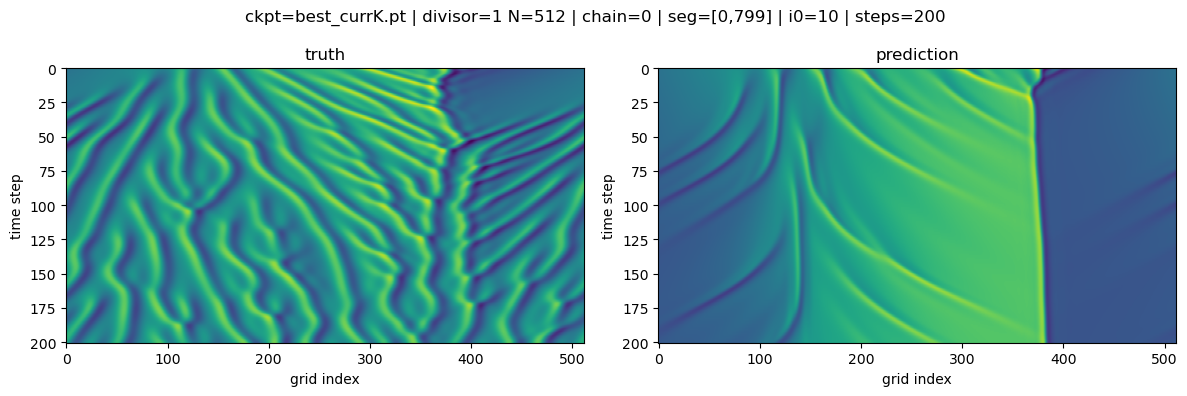

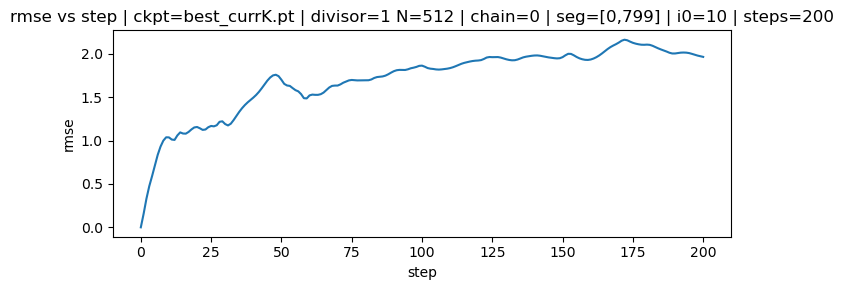

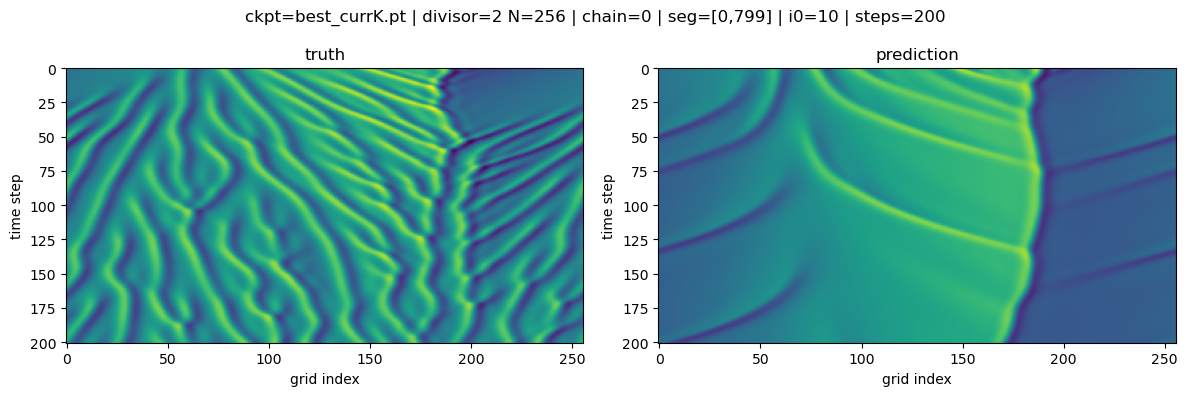

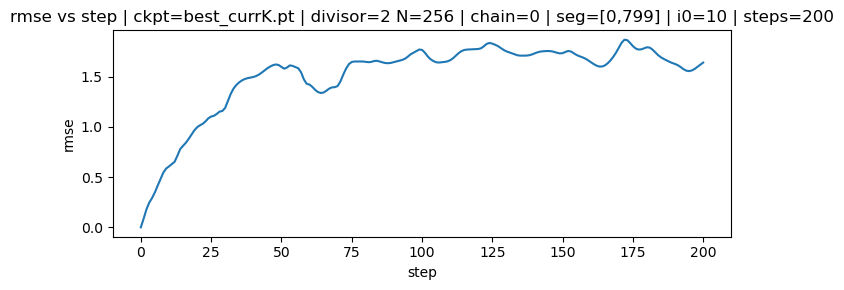

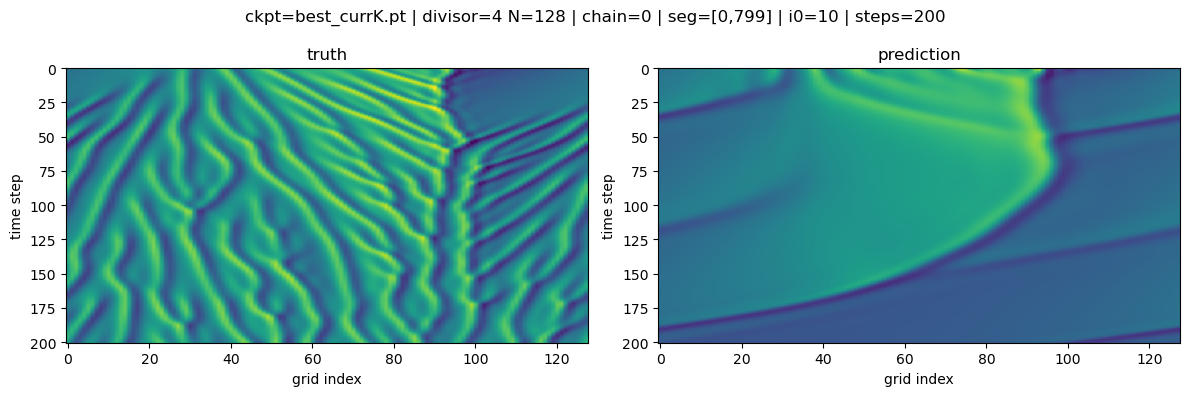

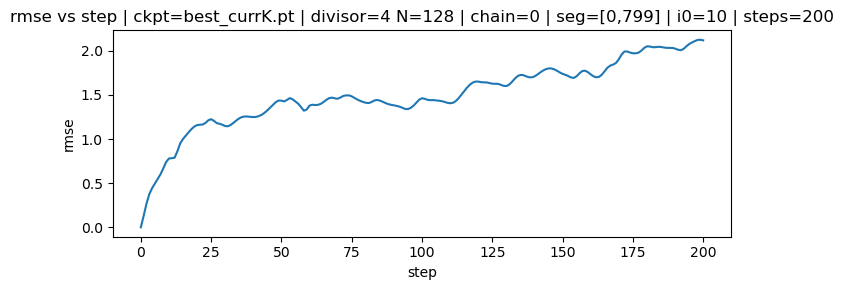

[done]


In [3]:
# ============================================
# Standalone: load best checkpoint + test + rollout
# ============================================
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------
# user knobs
# -----------------------
RUN_DIR = Path("runs_grid_agnostic_closed_loop_exp6_stable_v2")
DIVISORS = [1, 2, 4]
CHAIN_ID = 0
START_OFFSET = 10
ROLLOUT_STEPS = 200          # if your test seg is short, it will auto-fallback to full chain
ONE_STEP_SAMPLES = 4096      # how many one-step test points to sample
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# -----------------------

# -----------------------
# required globals from your training notebook/script
# -----------------------
need = ["model", "X_all", "norms", "Lx", "FREQS"]
missing = [k for k in need if k not in globals()]
if missing:
    raise RuntimeError(f"Missing globals in notebook: {missing}. Run the setup/training cells first so these exist.")

# optional globals (used if present)
dt = globals().get("dt", None)
include_dx = globals().get("include_dx", True)

# if te_segs/chains exist we'll use them; else fallback to a single segment covering all
te_segs = globals().get("te_segs", None)
chains  = globals().get("chains", None)
if te_segs is None and chains is None:
    chains = [(0, int(X_all.shape[0]-1))]

# -----------------------
# helpers
# -----------------------
def pick_best_ckpt(run_dir: Path) -> Path:
    for name in ["best_currK.pt", "best_one_step.pt", "last.pt"]:
        p = run_dir / name
        if p.exists():
            return p
    raise FileNotFoundError(f"No checkpoint found in {run_dir}. Expected one of best_currK.pt, best_one_step.pt, last.pt")

def extract_state_dict(ckpt_obj):
    # supports: {"model": state_dict}, {"state_dict": ...}, direct state_dict
    if isinstance(ckpt_obj, dict):
        for k in ["model", "state_dict", "model_state_dict", "net", "network"]:
            if k in ckpt_obj and isinstance(ckpt_obj[k], dict):
                return ckpt_obj[k]
    if isinstance(ckpt_obj, dict):
        # sometimes whole ckpt is already a state_dict
        # heuristic: lots of tensor values
        tensorish = sum([torch.is_tensor(v) for v in ckpt_obj.values()])
        if tensorish > 0:
            return ckpt_obj
    raise RuntimeError(f"Could not extract state_dict from checkpoint object keys={list(ckpt_obj.keys()) if isinstance(ckpt_obj, dict) else type(ckpt_obj)}")

def align_state_dict_to_model(sd: dict, model: torch.nn.Module) -> dict:
    model_keys = set(model.state_dict().keys())
    sd_keys = set(sd.keys())

    def strip_prefix(state, prefix):
        return { (k[len(prefix):] if k.startswith(prefix) else k): v for k, v in state.items() }

    def add_prefix(state, prefix):
        return { (prefix + k): v for k, v in state.items() }

    # torch.compile wrapper case
    sd_has_orig = any(k.startswith("_orig_mod.") for k in sd_keys)
    model_has_orig = any(k.startswith("_orig_mod.") for k in model_keys)

    if sd_has_orig and not model_has_orig:
        sd = strip_prefix(sd, "_orig_mod.")
        sd_keys = set(sd.keys())

    if (not sd_has_orig) and model_has_orig:
        sd = add_prefix(sd, "_orig_mod.")
        sd_keys = set(sd.keys())

    # DataParallel case
    sd_has_module = any(k.startswith("module.") for k in sd_keys)
    model_has_module = any(k.startswith("module.") for k in model_keys)

    if sd_has_module and not model_has_module:
        sd = strip_prefix(sd, "module.")
    if (not sd_has_module) and model_has_module:
        sd = add_prefix(sd, "module.")

    return sd

def downsample_mean(u_batch: np.ndarray, divisor: int) -> np.ndarray:
    # u_batch: (B, N0)
    if divisor == 1:
        return u_batch.astype(np.float32, copy=False)
    B, N0 = u_batch.shape
    assert N0 % divisor == 0
    N = N0 // divisor
    return u_batch.reshape(B, N, divisor).mean(axis=2).astype(np.float32)

# fallback posenc if your notebook doesn't already define it
if "posenc_from_x" not in globals():
    def posenc_from_x(x: np.ndarray, freqs):
        # x: (N,)
        # returns (2*len(freqs), N): [sin(2pi f x/L), cos(2pi f x/L)]
        x = x.astype(np.float32)
        feats = []
        for f in freqs:
            w = 2.0 * np.pi * float(f)
            feats.append(np.sin(w * x))
            feats.append(np.cos(w * x))
        return np.stack(feats, axis=0).astype(np.float32)

@torch.no_grad()
def one_step_rmse(divisor: int, n_samples: int = 4096, seed: int = 0):
    # sample indices i such that i-2 exists and i+1 exists within chosen segment
    rng = np.random.default_rng(seed)

    segs = te_segs if te_segs is not None else chains
    candidates = []
    for (s, e) in segs:
        lo = s + 2
        hi = e - 1
        if hi >= lo:
            # sample a few from each seg
            m = max(1, n_samples // max(1, len(segs)))
            picks = rng.integers(lo, hi + 1, size=m).tolist()
            candidates.extend(picks)

    if not candidates:
        raise RuntimeError("No valid indices for one-step test (segments too short?)")

    rng.shuffle(candidates)
    idx = np.array(candidates[:n_samples], dtype=np.int64)

    # build batch histories
    X0 = X_all[idx - 2]  # (B, N0)
    X1 = X_all[idx - 1]
    Xt = X_all[idx]
    Y1 = X_all[idx + 1]

    X0 = downsample_mean(X0, divisor)
    X1 = downsample_mean(X1, divisor)
    Xt = downsample_mean(Xt, divisor)
    Y1 = downsample_mean(Y1, divisor)

    N0 = X_all.shape[1]
    N = N0 // divisor
    dx = float(Lx) / float(N)
    x = (np.arange(N, dtype=np.float32) + 0.5) * dx
    pe = torch.from_numpy(posenc_from_x(x, FREQS)[None]).to(DEVICE)  # (1, P, N)

    scalars = [float(Lx)]
    if dt is not None:
        scalars.append(float(dt))
    if include_dx:
        scalars.append(float(dx))
    scalars = torch.tensor(scalars, dtype=torch.float32, device=DEVICE)[None, :]

    u_mean, u_std, du_mean, du_std = norms[divisor]

    # to torch
    u_tm2 = torch.from_numpy(X0[:, None, :]).to(DEVICE)
    u_tm1 = torch.from_numpy(X1[:, None, :]).to(DEVICE)
    u_t   = torch.from_numpy(Xt[:, None, :]).to(DEVICE)
    y_tp1 = torch.from_numpy(Y1).to(DEVICE)

    # normalize + forward
    u_tm2_n = (u_tm2 - u_mean) / u_std
    u_tm1_n = (u_tm1 - u_mean) / u_std
    u_t_n   = (u_t   - u_mean) / u_std
    prof = torch.cat([u_tm2_n, u_tm1_n, u_t_n, pe.repeat(u_t.shape[0], 1, 1)], dim=1)

    du_n = model(prof, scalars.repeat(u_t.shape[0], 1))
    du   = du_n * du_std + du_mean
    y_hat = (u_t + du).squeeze(1)  # (B, N)

    rmse = torch.sqrt(torch.mean((y_hat - y_tp1) ** 2)).item()
    return rmse

@torch.no_grad()
def rollout(chain_id: int, start_offset: int, steps: int, divisor: int):
    segs_test = te_segs if te_segs is not None else None
    segs_full = chains

    # choose segment for init; prefer test seg, fallback to full if too short for steps
    seg = None
    if segs_test is not None and chain_id < len(segs_test):
        seg = segs_test[chain_id]
        s, e = seg
        if (e - s + 1) < (steps + 3):
            seg = None
    if seg is None:
        seg = segs_full[chain_id]
    s, e = seg

    i0 = s + start_offset
    if i0 + steps + 1 > e:
        i0 = max(s + 2, e - steps - 1)  # push back into valid range

    N0 = X_all.shape[1]
    N = N0 // divisor
    dx = float(Lx) / float(N)
    x = (np.arange(N, dtype=np.float32) + 0.5) * dx
    pe = torch.from_numpy(posenc_from_x(x, FREQS)[None]).to(DEVICE)

    scalars = [float(Lx)]
    if dt is not None:
        scalars.append(float(dt))
    if include_dx:
        scalars.append(float(dx))
    scalars = torch.tensor(scalars, dtype=torch.float32, device=DEVICE)[None, :]

    u_mean, u_std, du_mean, du_std = norms[divisor]

    def down1(u1):
        u1 = u1.astype(np.float32, copy=False)[None, :]
        return downsample_mean(u1, divisor)[0]

    u_tm2 = torch.from_numpy(down1(X_all[i0 - 2])[None, None, :]).to(DEVICE)
    u_tm1 = torch.from_numpy(down1(X_all[i0 - 1])[None, None, :]).to(DEVICE)
    u_t   = torch.from_numpy(down1(X_all[i0      ])[None, None, :]).to(DEVICE)

    preds = [u_t.squeeze().cpu().numpy()]
    truth = [down1(X_all[i0]).copy()]

    for k in range(steps):
        u_tm2_n = (u_tm2 - u_mean) / u_std
        u_tm1_n = (u_tm1 - u_mean) / u_std
        u_t_n   = (u_t   - u_mean) / u_std
        prof = torch.cat([u_tm2_n, u_tm1_n, u_t_n, pe], dim=1)

        du_n = model(prof, scalars)
        du   = du_n * du_std + du_mean
        u_next = u_t + du

        u_tm2, u_tm1, u_t = u_tm1, u_t, u_next
        preds.append(u_next.squeeze().cpu().numpy())
        truth.append(down1(X_all[i0 + k + 1]).copy())

    preds = np.stack(preds, axis=0)
    truth = np.stack(truth, axis=0)
    rmse_curve = np.sqrt(((preds - truth) ** 2).mean(axis=1))
    return preds, truth, rmse_curve, (s, e, i0)

def plot_rollout(preds, truth, rmse_curve, title):
    vmin = min(truth.min(), preds.min())
    vmax = max(truth.max(), preds.max())

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].imshow(truth, aspect="auto", vmin=vmin, vmax=vmax)
    ax[0].set_title("truth")
    ax[1].imshow(preds, aspect="auto", vmin=vmin, vmax=vmax)
    ax[1].set_title("prediction")
    for a in ax:
        a.set_xlabel("grid index")
        a.set_ylabel("time step")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 3))
    plt.plot(rmse_curve)
    plt.title(f"rmse vs step | {title}")
    plt.xlabel("step")
    plt.ylabel("rmse")
    plt.tight_layout()
    plt.show()

# -----------------------
# load best checkpoint
# -----------------------
ckpt_path = pick_best_ckpt(RUN_DIR)
print(f"[eval] loading checkpoint: {ckpt_path}")
ckpt_obj = torch.load(ckpt_path, map_location=DEVICE)
sd = extract_state_dict(ckpt_obj)
sd = align_state_dict_to_model(sd, model)

model.to(DEVICE)
missing, unexpected = model.load_state_dict(sd, strict=False)
print(f"[eval] loaded. missing={len(missing)} unexpected={len(unexpected)}")
if len(missing) or len(unexpected):
    print("  (if missing/unexpected are only bn.num_batches_tracked, it’s fine)")

model.eval()

# -----------------------
# one-step test
# -----------------------
print("[test] one-step rmse (sampled from test segs if available)")
for d in DIVISORS:
    rmse = one_step_rmse(divisor=d, n_samples=ONE_STEP_SAMPLES, seed=0)
    print(f"  divisor={d} N={X_all.shape[1]//d} rmse={rmse:.6f}")

# -----------------------
# closed-loop rollout + plots
# -----------------------
print("[rollout] closed-loop")
for d in DIVISORS:
    preds, truth, rmse_curve, meta = rollout(
        chain_id=CHAIN_ID,
        start_offset=START_OFFSET,
        steps=ROLLOUT_STEPS,
        divisor=d,
    )
    s, e, i0 = meta
    title = f"ckpt={ckpt_path.name} | divisor={d} N={truth.shape[1]} | chain={CHAIN_ID} | seg=[{s},{e}] | i0={i0} | steps={ROLLOUT_STEPS}"
    plot_rollout(preds, truth, rmse_curve, title)

print("[done]")
